In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

deliveries = pd.read_csv('../data/deliveries.csv')

In [9]:
print(deliveries.columns)

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder', 'wicket_event', 'partnership_id'],
      dtype='object')


In [16]:
deliveries['is_wicket'] = deliveries['player_dismissed'].notnull().astype(int)

deliveries['partnership_id'] = deliveries['is_wicket'].cumsum()

partnerships = deliveries.groupby(['match_id', 'inning', 'partnership_id']).agg({
    'batting_team': 'first',
    'batter': 'unique', 
    'total_runs': 'sum'
}).reset_index()

partnerships = partnerships[partnerships['batter'].map(len) == 2]

top_partnership = partnerships.sort_values('total_runs', ascending=False).iloc[0]

print("--- SUCCESS! ---")
print(f"Top Partnership: {top_partnership['total_runs']} runs")
print(f"Players: {top_partnership['batter']}")
print(f"Team: {top_partnership['batting_team']}")

partnerships.sort_values('total_runs', ascending=False).head()

--- SUCCESS! ---
Top Partnership: 210 runs
Players: ['B Sai Sudharsan' 'Shubman Gill']
Team: Gujarat Titans


,match_id,inning,partnership_id,batting_team,batter,total_runs
14903,1426297,1,12779,Gujarat Titans,"[B Sai Sudharsan, Shubman Gill]",210
12905,1304112,1,11058,Lucknow Super Giants,"[Q de Kock, KL Rahul]",210
9649,1175366,1,8271,Sunrisers Hyderabad,"[JM Bairstow, DA Warner]",185
7886,1082593,2,6756,Kolkata Knight Riders,"[G Gambhir, CA Lynn]",184
10808,1216527,1,9255,Kings XI Punjab,"[KL Rahul, MA Agarwal]",183


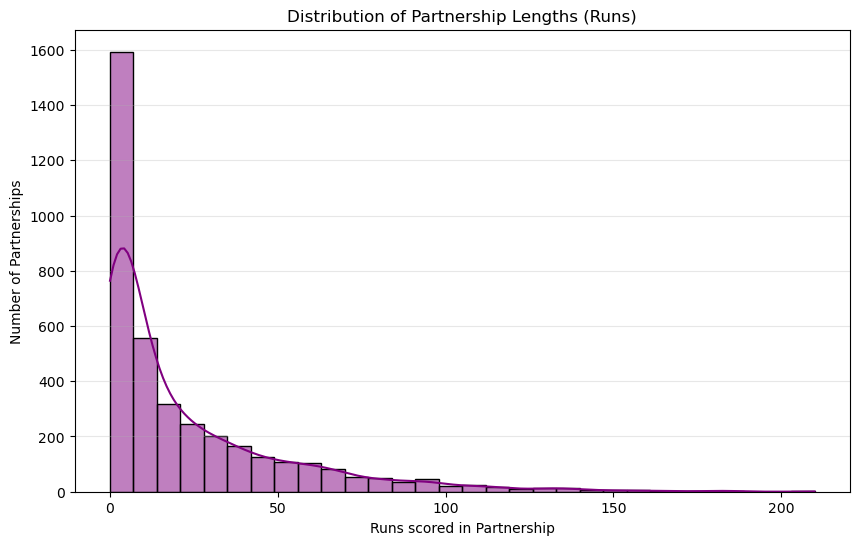

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(partnerships['total_runs'], bins=30, kde=True, color='purple')

plt.title('Distribution of Partnership Lengths (Runs)')
plt.xlabel('Runs scored in Partnership')
plt.ylabel('Number of Partnerships')
plt.grid(axis='y', alpha=0.3)
plt.show()